# Task A: Dataset Audit and Variable Classification

## **Task A1:** Structural Inspection

In [ ]:
import pandas as pd
import numpy as np

# Load csv
df = pd.read_csv("FIFA WC 2022 Players Stats.csv")
df.head()

,Nationality,FIFA Ranking,National Team Kit Sponsor,Position,National Team Jersey Number,Player DOB,Club,Player Name,Appearances,Goals Scored,Assists Provided,Dribbles per 90,Interceptions per 90,Tackles per 90,Total Duels Won per 90,Save Percentage,Clean Sheets,Brand Sponsor/Brand Used
0,Argentina,2,Adidas,GK,23.0,"Sep 2, 1992",Aston Villa,Emiliano Martinez,7,0,0,0.00,0.00,0.00,0.65,46.67%,43%,Adidas
1,Argentina,2,Adidas,GK,1.0,"Oct 16, 1986",River,Franco Armani,0,-,-,-,-,-,-,-,-,Nike
2,Argentina,2,Adidas,GK,12.0,"May 20, 1992",Villarreal,Geronimo Rulli,0,-,-,-,-,-,-,-,-,Adidas
3,Argentina,2,Adidas,DF,19.0,"Feb 12, 1988",Benfica,Nicolas Otamendi,7,0,1,0.33,1.17,1.30,7.17,-,-,Nike
4,Argentina,2,Adidas,DF,8.0,"Oct 28, 1991",Sevilla,Marcos Acuna,6,0,0,1.45,0.48,2.90,7.97,-,-,Nike


In [ ]:
print("Shape:", df.shape)
df.columns

Shape: (814, 18)


Index(['Nationality ', 'FIFA Ranking ', 'National Team Kit Sponsor',
       'Position', 'National Team Jersey Number', 'Player DOB', 'Club ',
       'Player Name ', ' Appearances', 'Goals Scored ', 'Assists Provided ',
       'Dribbles per 90', 'Interceptions per 90', 'Tackles per 90',
       'Total Duels Won per 90', 'Save Percentage', 'Clean Sheets',
       'Brand Sponsor/Brand Used'],
      dtype='object')

The dataset contains 814 player records with 18 input features. It captures demographic details (nationality, age, club), performance statistics (appearances, goals, assists, dribbles, tackles, duels, saves, clean sheets), and sponsorship information (national kit sponsor, brand sponsor).

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 814 entries, 0 to 813
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Nationality                  814 non-null    object 
 1   FIFA Ranking                 814 non-null    int64  
 2   National Team Kit Sponsor    813 non-null    object 
 3   Position                     814 non-null    object 
 4   National Team Jersey Number  813 non-null    float64
 5   Player DOB                   814 non-null    object 
 6   Club                         814 non-null    object 
 7   Player Name                  814 non-null    object 
 8    Appearances                 814 non-null    object 
 9   Goals Scored                 813 non-null    object 
 10  Assists Provided             813 non-null    object 
 11  Dribbles per 90              813 non-null    object 
 12  Interceptions per 90         813 non-null    object 
 13  Tackles per 90      

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
# Convert Player DOB data type into datetime
df['Player DOB'] = pd.to_datetime(df['Player DOB'], format='mixed', errors='coerce')
print(df['Player DOB'].head())


0   1992-09-02
1   1986-10-16
2   1992-05-20
3   1988-02-12
4   1991-10-28
Name: Player DOB, dtype: datetime64[ns]


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 814 entries, 0 to 813
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Nationality                  814 non-null    object        
 1   FIFA Ranking                 814 non-null    int64         
 2   National Team Kit Sponsor    813 non-null    object        
 3   Position                     814 non-null    object        
 4   National Team Jersey Number  813 non-null    float64       
 5   Player DOB                   814 non-null    datetime64[ns]
 6   Club                         814 non-null    object        
 7   Player Name                  814 non-null    object        
 8   Appearances                  814 non-null    object        
 9   Goals Scored                 813 non-null    object        
 10  Assists Provided             813 non-null    object        
 11  Dribbles per 90              813 non-null    

In [ ]:
df.duplicated().sum()

np.int64(0)

No duplicate records were found in the dataset. Therefore, no rows were removed at this stage.

In [ ]:
# List the numeric columns
numeric_cols = [
    'Appearances','Goals Scored','Assists Provided',
    'Dribbles per 90','Interceptions per 90','Tackles per 90',
    'Total Duels Won per 90','Save Percentage','Clean Sheets'
]

# Remove '%' from percentage columns
df['Save Percentage'] = df['Save Percentage'].str.replace('%','', regex=False)
df['Clean Sheets'] = df['Clean Sheets'].str.replace('%','', regex=False)

# Replace non-numeric placeholders with NaN
df[numeric_cols] = df[numeric_cols].replace(['-', 'N,A', 'N.A', ''], np.nan)

# Convert all the numeric columns into the correct data type
df[numeric_cols] = df[numeric_cols].astype(float)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 814 entries, 0 to 813
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Nationality                  814 non-null    object        
 1   FIFA Ranking                 814 non-null    int64         
 2   National Team Kit Sponsor    813 non-null    object        
 3   Position                     814 non-null    object        
 4   National Team Jersey Number  813 non-null    float64       
 5   Player DOB                   814 non-null    datetime64[ns]
 6   Club                         814 non-null    object        
 7   Player Name                  814 non-null    object        
 8   Appearances                  661 non-null    float64       
 9   Goals Scored                 584 non-null    float64       
 10  Assists Provided             584 non-null    float64       
 11  Dribbles per 90              563 non-null    

## Task A3: Missing Data Diagnosis

In [ ]:
missing_counts = df.isnull().sum()
missing_percentage = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_percentage.round(2)
})

In [ ]:
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]
missing_summary

,Missing Count,Missing Percentage (%)
National Team Kit Sponsor,1,0.12
National Team Jersey Number,1,0.12
Appearances,153,18.80
Goals Scored,230,28.26
Assists Provided,230,28.26
Dribbles per 90,251,30.84
Interceptions per 90,251,30.84
Tackles per 90,259,31.82
Total Duels Won per 90,281,34.52
Save Percentage,776,95.33


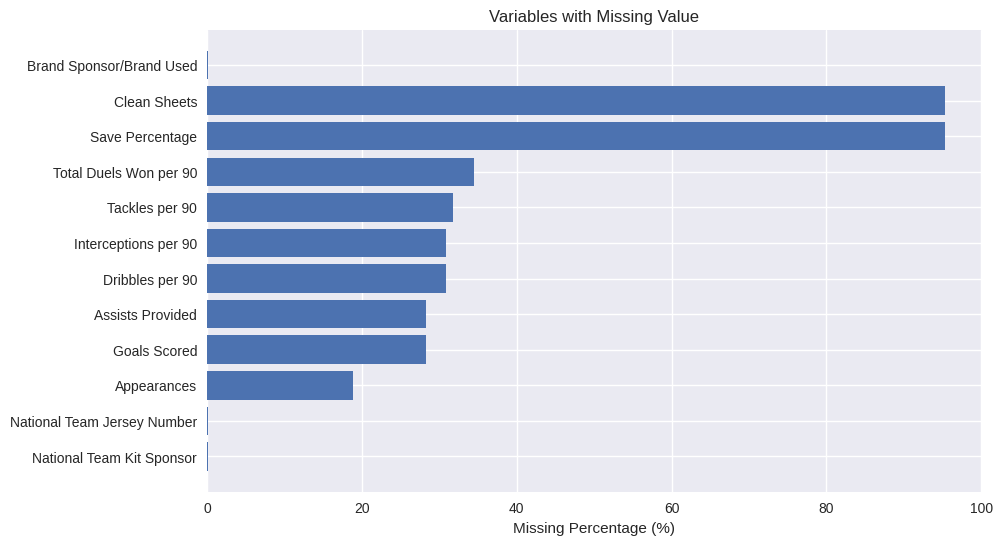

In [ ]:
import matplotlib.pyplot as plt

# Create visualisation for missing values
plt.figure(figsize=(10,6))
plt.barh(missing_summary.index, missing_summary["Missing Percentage (%)"])
plt.xlabel("Missing Percentage (%)")
plt.title("Variables with Missing Value")
plt.show()

In [ ]:
# Drop rows with any missing values
df_deleted = df.copy()
df_deleted = df_deleted.dropna(subset=numeric_cols)

print("Original shape:", df.shape)
print("After deletion:", df_deleted.shape)

Original shape: (814, 18)
After deletion: (1, 18)


In this project, delete the missing values are not suitable. Best used when missingness is MCAR, so deletion does not bias the dataset.

In [ ]:
df_imputed = df.copy()

for col in numeric_cols:
    median_val = df_imputed[col].median()
    df_imputed[col].fillna(median_val, inplace=True)

print(df_imputed[numeric_cols].isnull().sum())

Appearances               0
Goals Scored              0
Assists Provided          0
Dribbles per 90           0
Interceptions per 90      0
Tackles per 90            0
Total Duels Won per 90    0
Save Percentage           0
Clean Sheets              0
dtype: int64


/tmp/ipykernel_538/790266401.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed[col].fillna(median_val, inplace=True)


Median is robust to skew and outliers and avoids bias from dropping rows. Median Imputation is suitable while handling MAR and the distribution is skewed.

In [ ]:
# Impute missing values with 0
df[numeric_cols] = df[numeric_cols].fillna(0)

print(df[numeric_cols].isnull().sum())

Appearances               0
Goals Scored              0
Assists Provided          0
Dribbles per 90           0
Interceptions per 90      0
Tackles per 90            0
Total Duels Won per 90    0
Save Percentage           0
Clean Sheets              0
dtype: int64


Replacing missing numeric values with 0 is consistent with the semantics of player data. It encodes absence of participation or applicability, which is more meaningful than median/mean imputation in this context.

In [ ]:
# Strategy 1: Delete rows
mean_deleted = df_deleted[numeric_cols].mean()
std_deleted = df_deleted[numeric_cols].std()

# Strategy 2: Median Imputation
mean_median = df_imputed[numeric_cols].mean()
std_median = df_imputed[numeric_cols].std()

# Strategy 3: Zero Imputation
mean_zero = df[numeric_cols].mean()
std_zero = df[numeric_cols].std()

# Compare results
comparison = pd.DataFrame({
    "Mean (Delete Rows)": mean_deleted,
    "Std (Delete Rows)": std_deleted,
    "Mean (Median Imputation)": mean_median,
    "Std (Median Imputation)": std_median,
    "Mean (Zero Imputation)": mean_zero,
    "Std (Zero Imputation)": std_zero
})

print(comparison)

                        Mean (Delete Rows)  Std (Delete Rows)  \
Appearances                           7.00                NaN   
Goals Scored                          0.00                NaN   
Assists Provided                      0.00                NaN   
Dribbles per 90                       0.00                NaN   
Interceptions per 90                  0.00                NaN   
Tackles per 90                        0.00                NaN   
Total Duels Won per 90                0.65                NaN   
Save Percentage                      46.67                NaN   
Clean Sheets                         43.00                NaN   

                        Mean (Median Imputation)  Std (Median Imputation)  \
Appearances                             2.863636                 1.498611   
Goals Scored                            0.203931                 0.639176   
Assists Provided                        0.136364                 0.437852   
Dribbles per 90                         1